In [1]:
%run -i ../../python_scripts/nb_setup.py

GPU Available: False


#### Loading dataset with confidence function (SR or MCD)

In [2]:
sgp_df_SR = pickle.load(open("sgp_set_cnn", "rb"))
print(
    "N =", sgp_df_SR.shape[0], "1s prop = ", sgp_df_SR.y_true.sum() / sgp_df_SR.shape[0]
)
sgp_df_SR.head(3)

N = 6788 1s prop =  0.3320565704183854


,y_true,y_pred,kappa
0,0.0,0.0,0.985617
1,1.0,1.0,0.899486
2,1.0,1.0,0.952112


In [3]:
sgp_df_MCD = pickle.load(open("sgp_set_cnn_MCD", "rb"))
sgp_df_MCD.head(3)

,y_true,y_pred,kappa
0,0.0,0.0,-0.000600
1,1.0,1.0,-0.003494
2,1.0,1.0,-0.001536


#### Random split into bounds-fitting and bounds-testing (with reproducible seed)

In [4]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=26
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(sgp_df_MCD, seed=26)

Setting experiments parameters

In [5]:
theta_min_SR, theta_max_SR = 0.5, 1  # Sn-independent grid
theta_min_MCD, theta_max_MCD = -0.05, 0  # Sn-independent grid

In [6]:
color_map = {
    "standard": "#d51414",
    "FP": "#a08611",
    "FN": "#1c9815",
    "FPR": "#403535",
    "FNR": "#1d3ae2",
    "SE": "#d51de2",
    "SP": "#118997",
    "PPV": "#676767",
}

#### Joint evolution of metrics with respect to $\theta$ and coverage

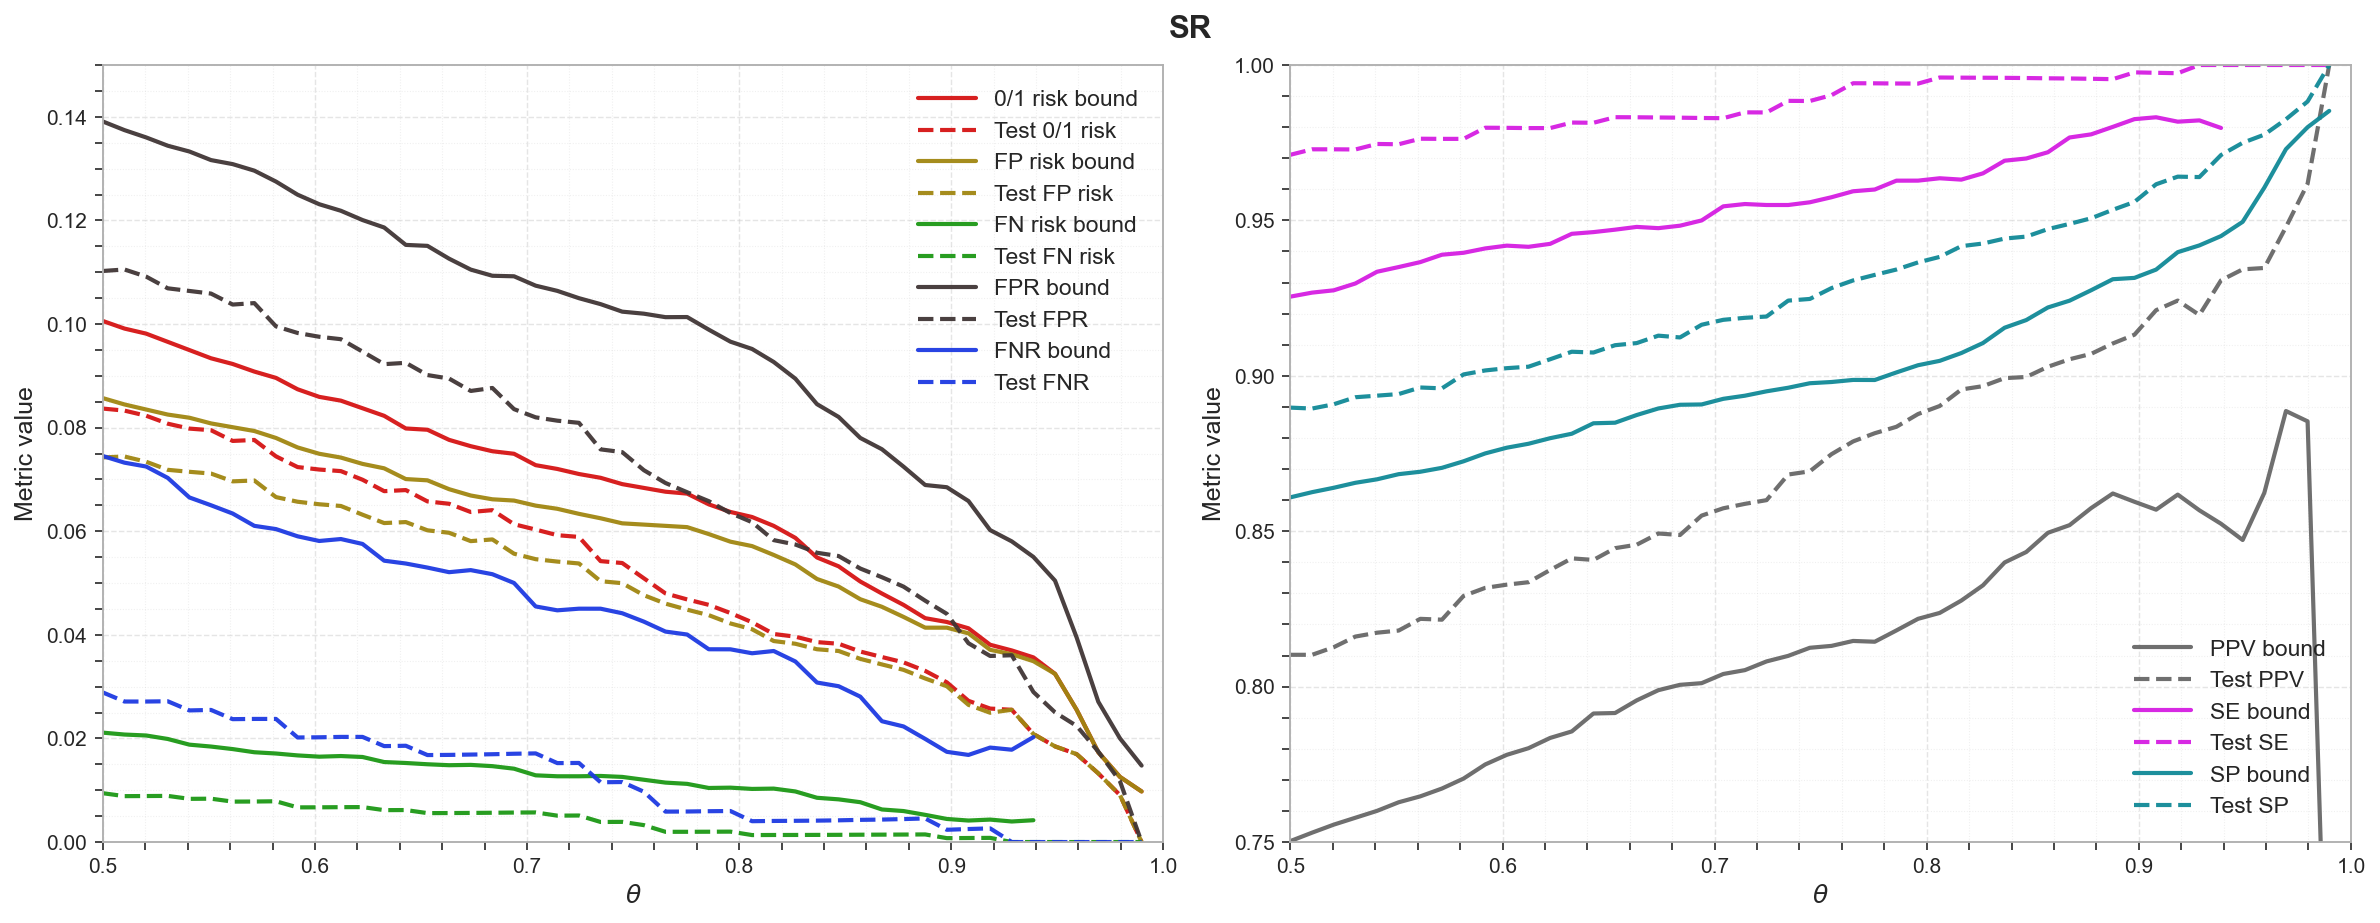

In [7]:
plot_all_metrics(
    train_set_SR,
    test_set_SR,
    color_map,
    title="SR",
    xlim1=[0.5, 1],
    xlim2=[0.5, 1],
    ylim1=[0, 0.15],
    ylim2=[0.75, 1],
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)

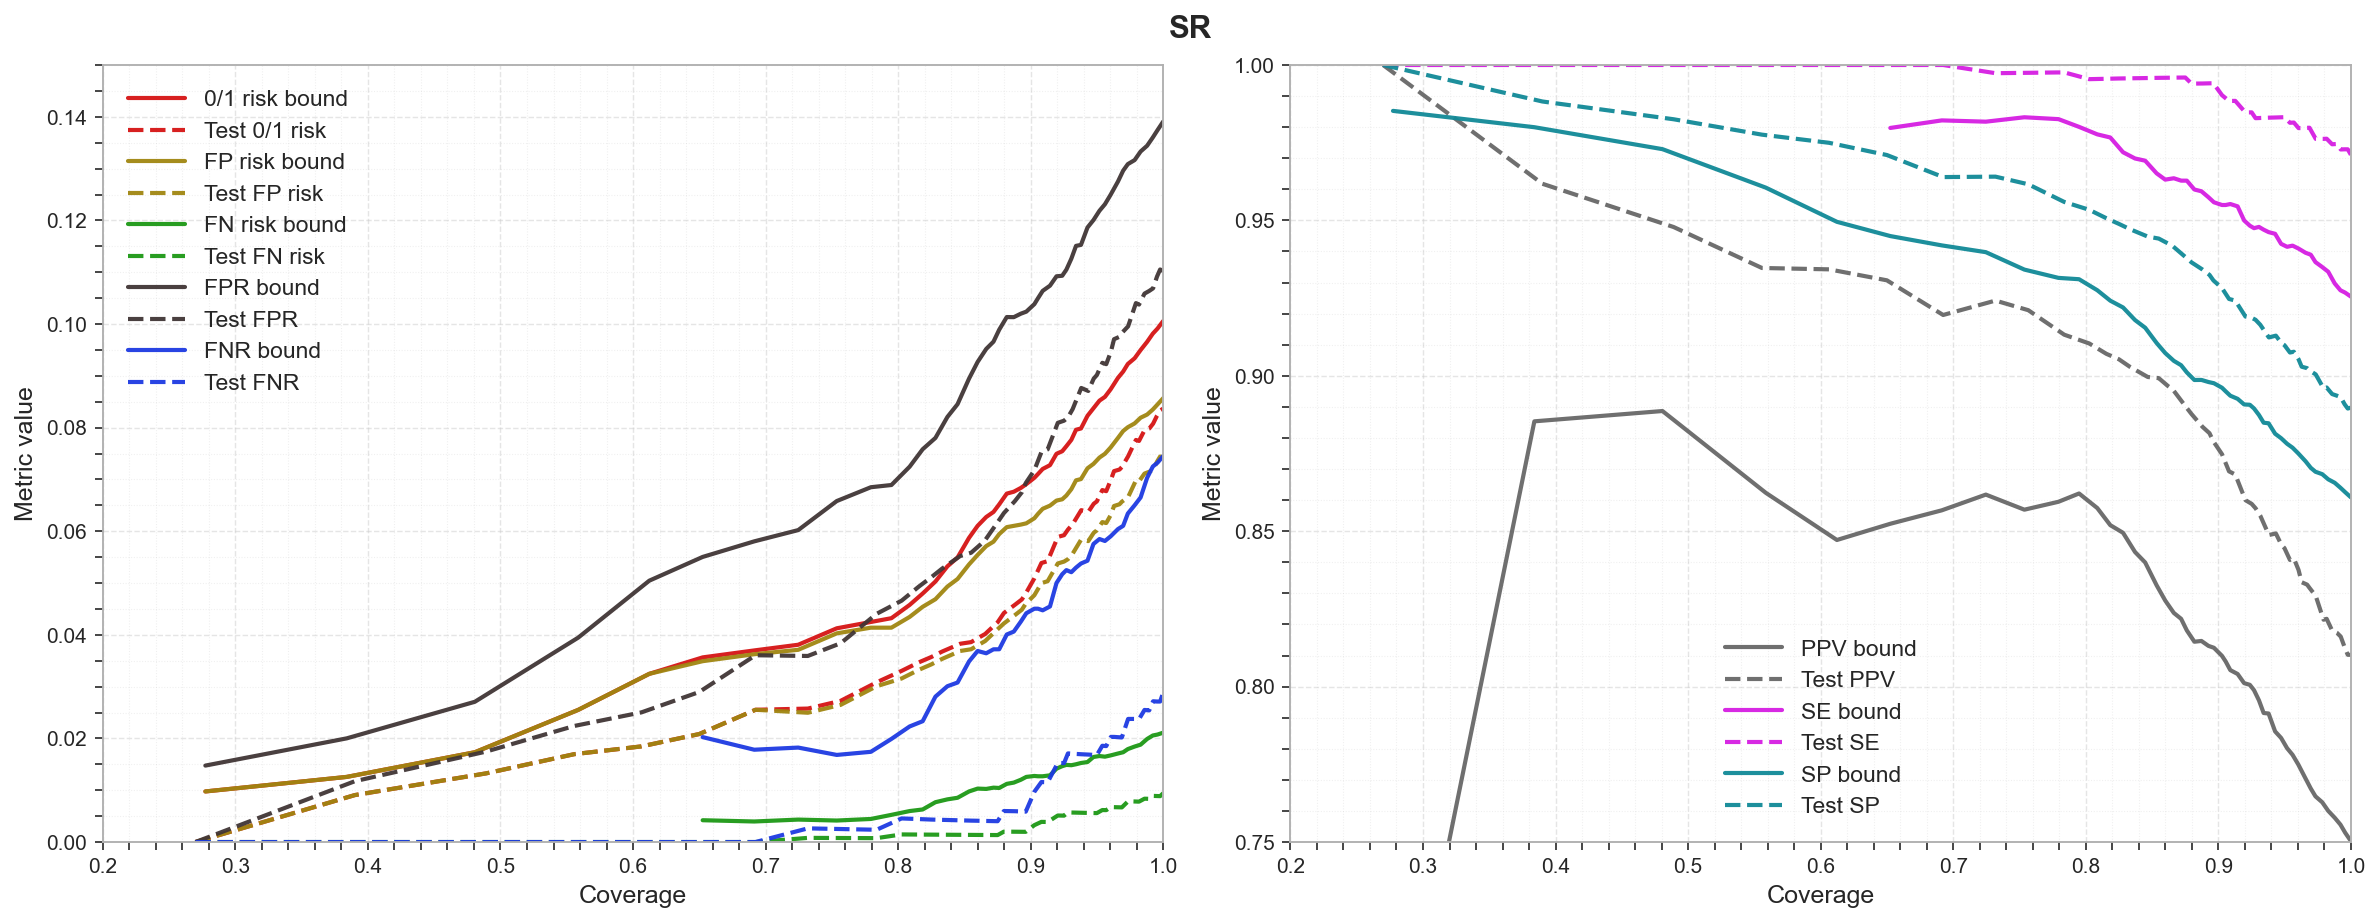

In [8]:
plot_all_metrics(
    train_set_SR,
    test_set_SR,
    color_map,
    title="SR",
    xlim1=[0.2, 1],
    xlim2=[0.2, 1],
    ylim1=[0, 0.15],
    ylim2=[0.75, 1],
    by_coverage=True,
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)

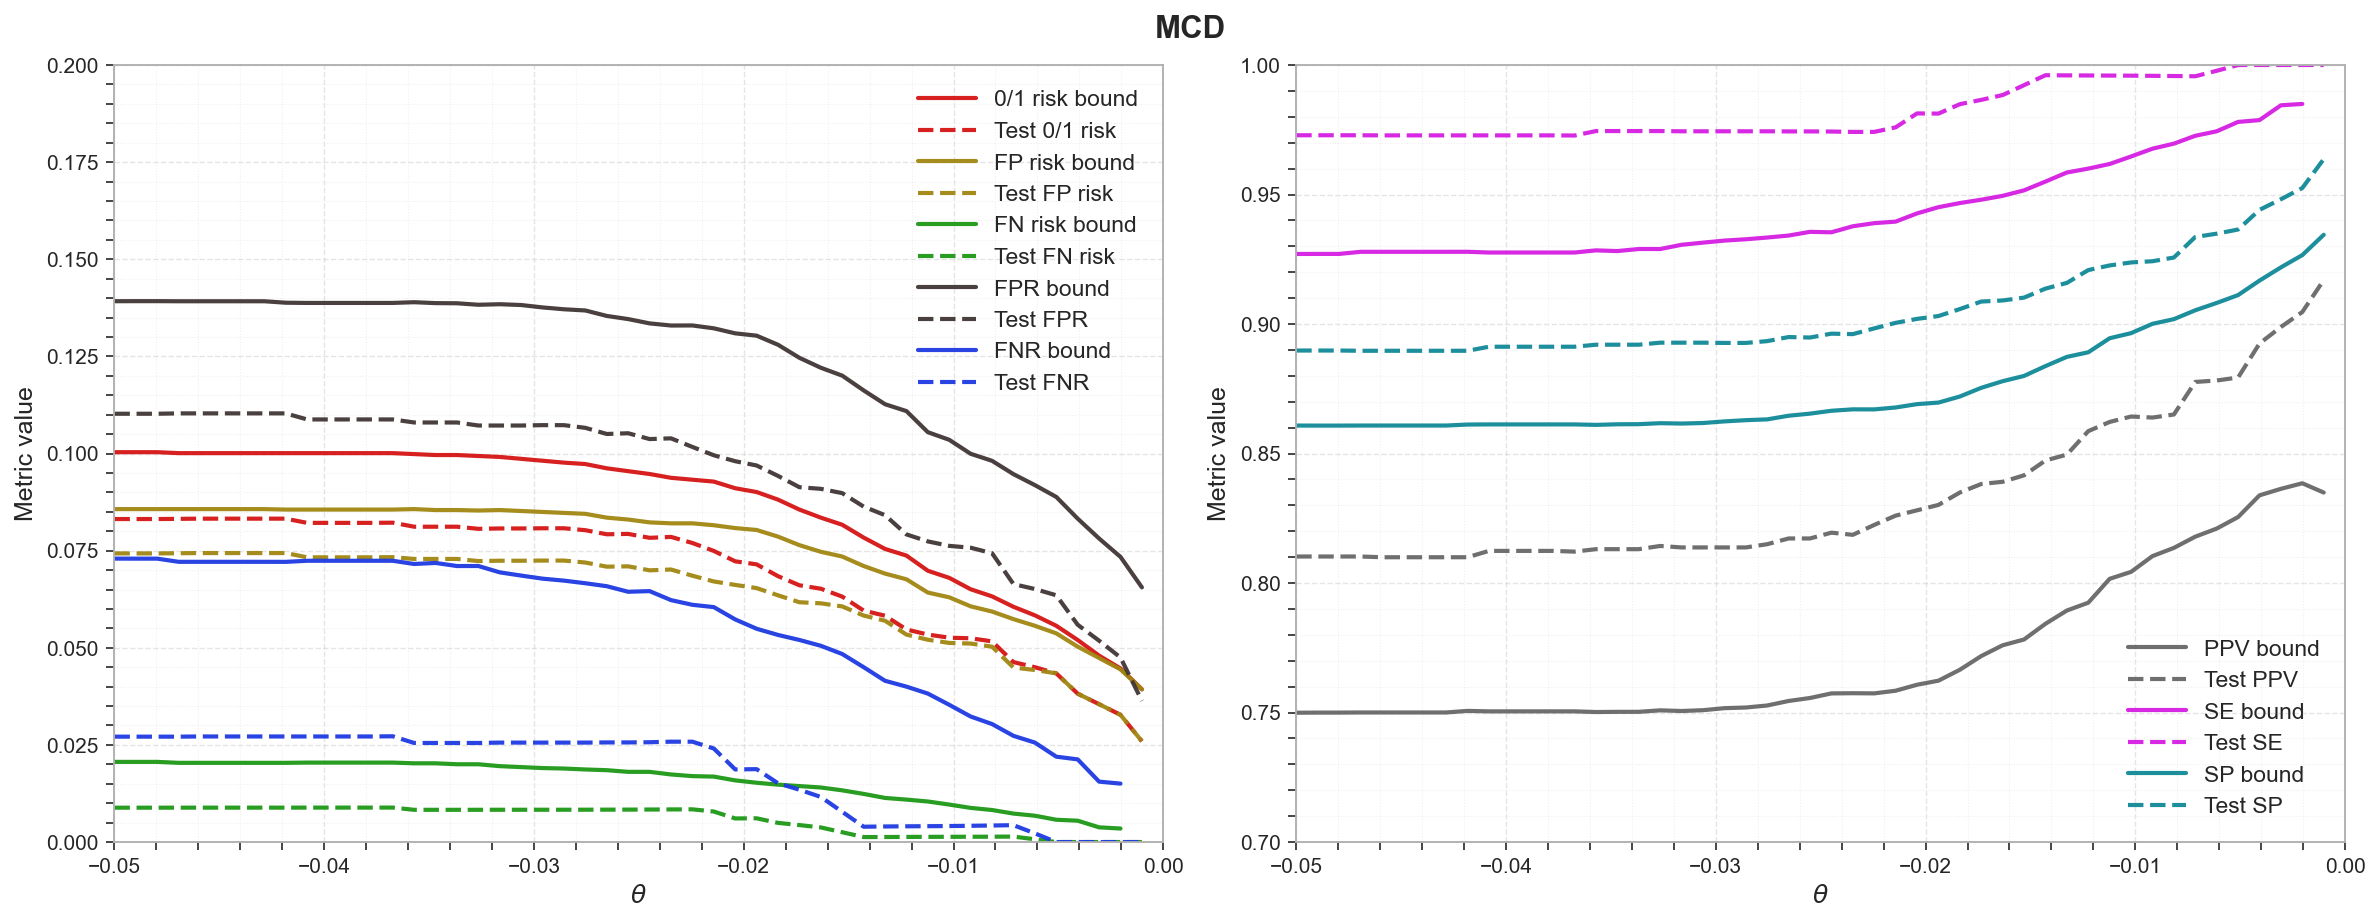

In [9]:
plot_all_metrics(
    train_set_MCD,
    test_set_MCD,
    color_map,
    title="MCD",
    xlim1=[-0.07, 0],
    xlim2=[-0.07, 0],
    ylim1=[0, 0.2],
    ylim2=[0.7, 1],
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)

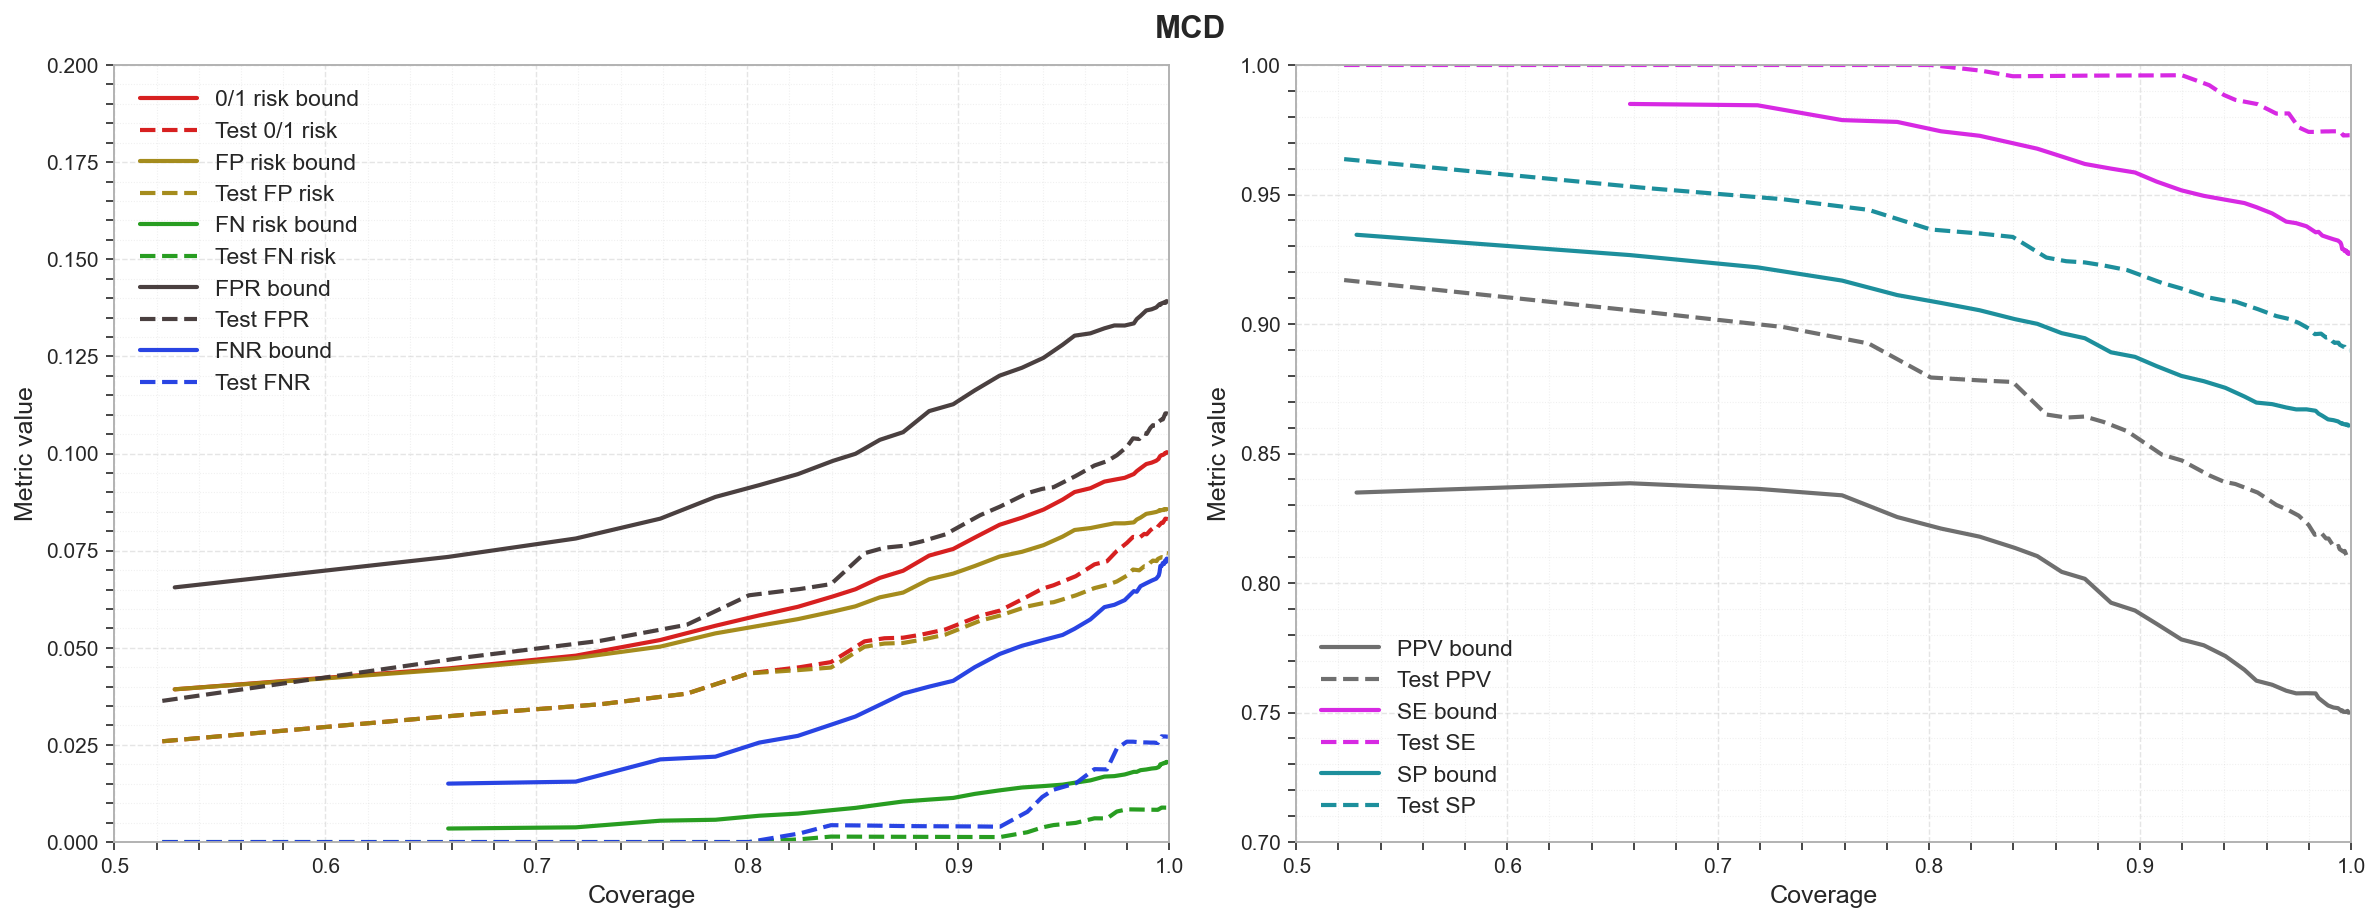

In [10]:
plot_all_metrics(
    train_set_MCD,
    test_set_MCD,
    color_map,
    title="MCD",
    xlim1=[0.5, 1],
    xlim2=[0.5, 1],
    ylim1=[0, 0.2],
    ylim2=[0.7, 1],
    by_coverage=True,
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)

#### Finding $\theta^*$ for joint control, if solutions set is non empty

In [11]:
metrics_and_targets = {"FNR": 0.2, "FPR": 0.1}

In [12]:
joint_output = joint_control(
    metrics_and_targets,
    train_set_SR,
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
    plot=False,
)
joint_output

{'theta_intervals': [(np.float64(0.7857142857142857),
   np.float64(0.9387755102040816))],
 'best_theta': np.float64(0.7857142857142857)}

#### Displaying all bounds trade-offs for a couple of 2 metrics

In [13]:
metrics = ["standard", "FP", "FN", "FPR", "FNR", "PPV", "SE", "SP"]

all_bounds_SR = reachable_bounds(
    metrics, train_set_SR, theta_min=theta_min_SR, theta_max=theta_max_SR
)
all_bounds_MCD = reachable_bounds(
    metrics, train_set_MCD, theta_min=theta_min_MCD, theta_max=theta_max_MCD
)

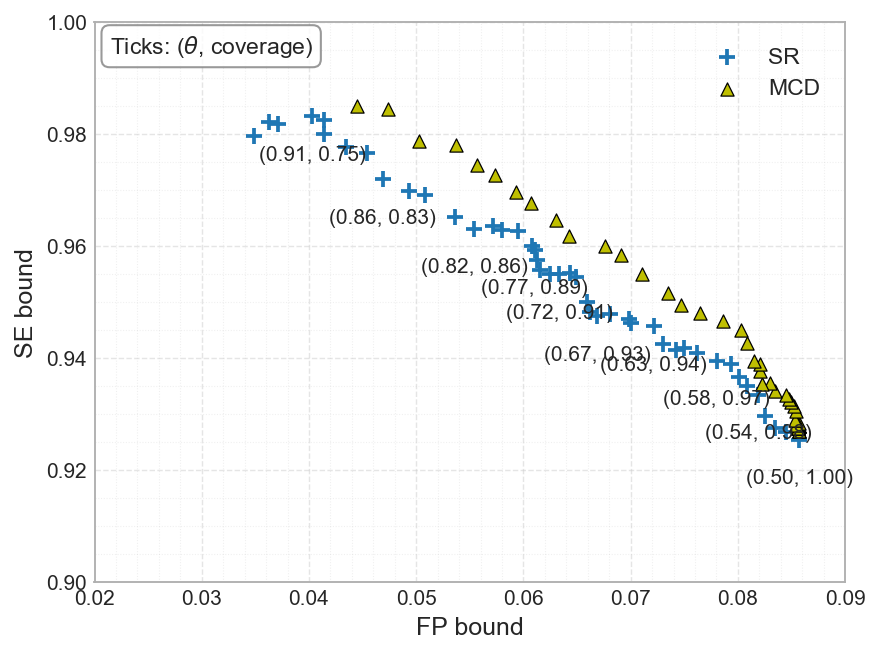

In [14]:
metric1 = "FP"
metric2 = "SE"

two_metrics_bounds(
    metric1,
    metric2,
    all_bounds_SR,
    all_bounds_MCD=all_bounds_MCD,
    num_labels=12,
    xlim=[0.02, 0.09],
    ylim=[0.9, 1],
)